# Cell 1 - Markdown
"""
# 04 Imbalance Handling and Hyperparameter Tuning

## Student Performance Prediction Using Machine Learning

This notebook improves the baseline models by addressing class imbalance and tuning model parameters.

Main tasks:
- Load cleaned data
- Rebuild the same train/test split
- Apply class weighting
- Apply SMOTE as an additional experiment
- Apply GridSearchCV
- Apply threshold tuning
- Compare all improved models
- Save the best candidate model
"""

In [1]:
# Cell 2 - Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# Cell 3 - Optional SMOTE Import

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
    print("imbalanced-learn is available. SMOTE experiments can be used.")
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn is not available. SMOTE experiments will be skipped.")

imbalanced-learn is available. SMOTE experiments can be used.


In [4]:
# Cell 4 - Define Paths

PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "StudentPerformanceFactors_cleaned.csv"

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Cleaned data path:", DATA_PATH)
print("Figures directory:", FIGURES_DIR)
print("Tables directory:", TABLES_DIR)
print("Models directory:", MODELS_DIR)

Cleaned data path: ..\data\processed\StudentPerformanceFactors_cleaned.csv
Figures directory: ..\outputs\figures
Tables directory: ..\outputs\tables
Models directory: ..\outputs\models


In [5]:
# Cell 5 - Load Dataset

df = pd.read_csv(DATA_PATH)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance_Label,Pass_Fail
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,Pass,1
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,Pass,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Pass,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Pass,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70,Pass,1


In [6]:
# Cell 6 - Target Distribution

target_counts = df["Performance_Label"].value_counts()
target_percentages = df["Performance_Label"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Class": target_counts.index,
    "Count": target_counts.values,
    "Percentage (%)": target_percentages.round(2).values
})

target_summary

,Class,Count,Percentage (%)
0,Pass,6539,98.97
1,Fail,68,1.03


In [7]:
# Cell 7 - Define Features and Target

target = "Pass_Fail"

drop_columns = [
    "Exam_Score",
    "Performance_Label",
    "Pass_Fail"
]

X = df.drop(columns=drop_columns)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (6607, 19)
Target vector shape: (6607,)

Target distribution:
Pass_Fail
1    6539
0      68
Name: count, dtype: int64


In [8]:
# Cell 8 - Identify Numerical and Categorical Features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical Features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [9]:
# Cell 9 - Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (5285, 19)
Testing set shape: (1322, 19)

Training target distribution:
Pass_Fail
1    5231
0      54
Name: count, dtype: int64

Testing target distribution:
Pass_Fail
1    1308
0      14
Name: count, dtype: int64


In [10]:
# Cell 10 - Build Preprocessing Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [11]:
# Cell 11 - Evaluation Function

def evaluate_model(model_name, strategy, y_true, y_pred):
    return {
        "Model": model_name,
        "Strategy": strategy,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_Weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Fail_Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fail_Precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Pass_Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

In [12]:
# Cell 12 - Confusion Matrix Function

def plot_confusion_matrix(model_name, strategy, y_true, y_pred, save=True):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Fail", "Predicted Pass"],
        yticklabels=["Actual Fail", "Actual Pass"]
    )

    plt.title(f"Confusion Matrix - {model_name} ({strategy})", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()

    if save:
        clean_model = model_name.lower().replace(" ", "_")
        clean_strategy = strategy.lower().replace(" ", "_").replace("=", "")
        file_name = f"confusion_matrix_{clean_model}_{clean_strategy}.png"
        plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")

    plt.show()

    return cm

In [13]:
# Cell 13 - Define Class-Weighted Models

weighted_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    )
}

Training class-weighted model: Logistic Regression
              precision    recall  f1-score   support

        Fail       0.48      1.00      0.65        14
        Pass       1.00      0.99      0.99      1308

    accuracy                           0.99      1322
   macro avg       0.74      0.99      0.82      1322
weighted avg       0.99      0.99      0.99      1322



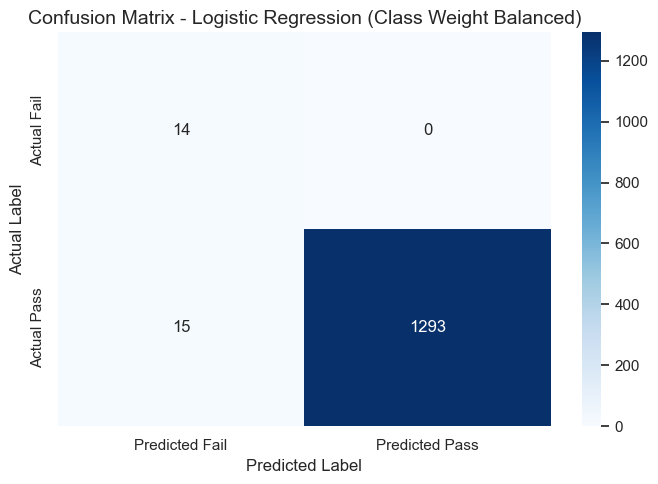

Training class-weighted model: Decision Tree
              precision    recall  f1-score   support

        Fail       0.33      0.29      0.31        14
        Pass       0.99      0.99      0.99      1308

    accuracy                           0.99      1322
   macro avg       0.66      0.64      0.65      1322
weighted avg       0.99      0.99      0.99      1322



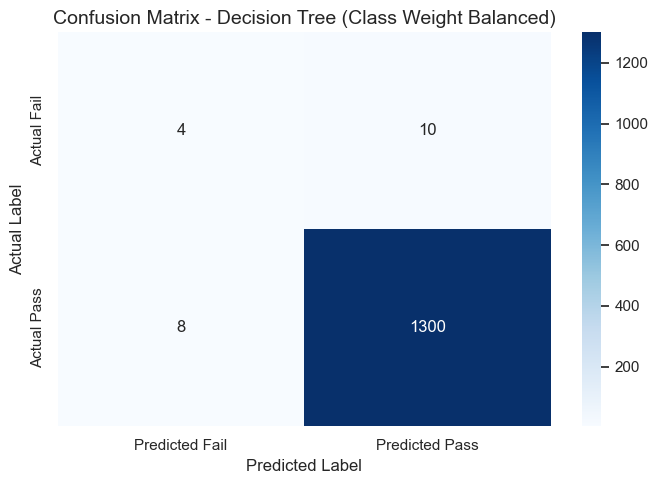

Training class-weighted model: Random Forest
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        14
        Pass       0.99      1.00      0.99      1308

    accuracy                           0.99      1322
   macro avg       0.49      0.50      0.50      1322
weighted avg       0.98      0.99      0.98      1322



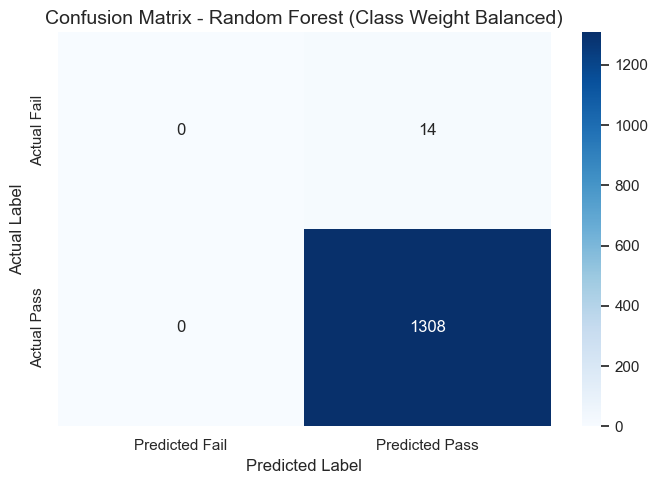

Training class-weighted model: SVM
              precision    recall  f1-score   support

        Fail       0.67      0.57      0.62        14
        Pass       1.00      1.00      1.00      1308

    accuracy                           0.99      1322
   macro avg       0.83      0.78      0.81      1322
weighted avg       0.99      0.99      0.99      1322



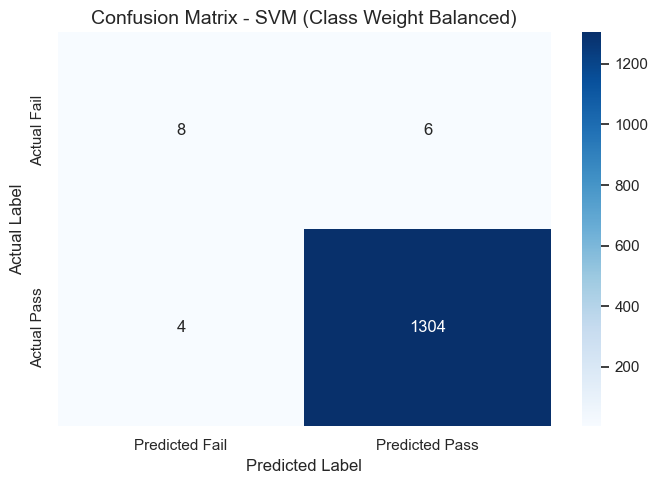

In [14]:
# Cell 14 - Train and Evaluate Class-Weighted Models

imbalance_results = []
weighted_pipelines = {}

for model_name, model in weighted_models.items():
    print("=" * 80)
    print(f"Training class-weighted model: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    result = evaluate_model(
        model_name=model_name,
        strategy="Class Weight Balanced",
        y_true=y_test,
        y_pred=y_pred
    )

    imbalance_results.append(result)
    weighted_pipelines[model_name] = pipeline

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    ))

    plot_confusion_matrix(
        model_name=model_name,
        strategy="Class Weight Balanced",
        y_true=y_test,
        y_pred=y_pred
    )

Training class-weighted model: Logistic Regression
              precision    recall  f1-score   support

        Fail       0.48      1.00      0.65        14
        Pass       1.00      0.99      0.99      1308

    accuracy                           0.99      1322
   macro avg       0.74      0.99      0.82      1322
weighted avg       0.99      0.99      0.99      1322



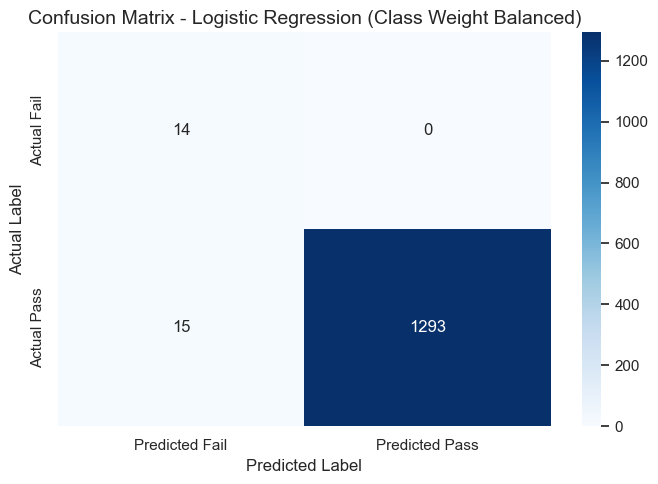

Training class-weighted model: Decision Tree
              precision    recall  f1-score   support

        Fail       0.33      0.29      0.31        14
        Pass       0.99      0.99      0.99      1308

    accuracy                           0.99      1322
   macro avg       0.66      0.64      0.65      1322
weighted avg       0.99      0.99      0.99      1322



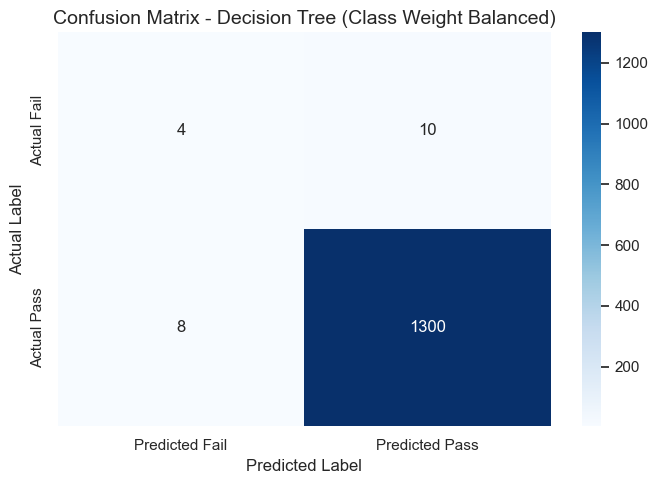

Training class-weighted model: Random Forest
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        14
        Pass       0.99      1.00      0.99      1308

    accuracy                           0.99      1322
   macro avg       0.49      0.50      0.50      1322
weighted avg       0.98      0.99      0.98      1322



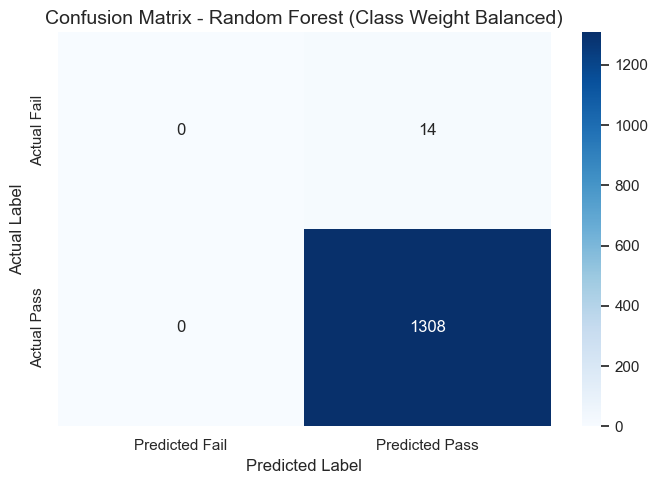

Training class-weighted model: SVM
              precision    recall  f1-score   support

        Fail       0.67      0.57      0.62        14
        Pass       1.00      1.00      1.00      1308

    accuracy                           0.99      1322
   macro avg       0.83      0.78      0.81      1322
weighted avg       0.99      0.99      0.99      1322



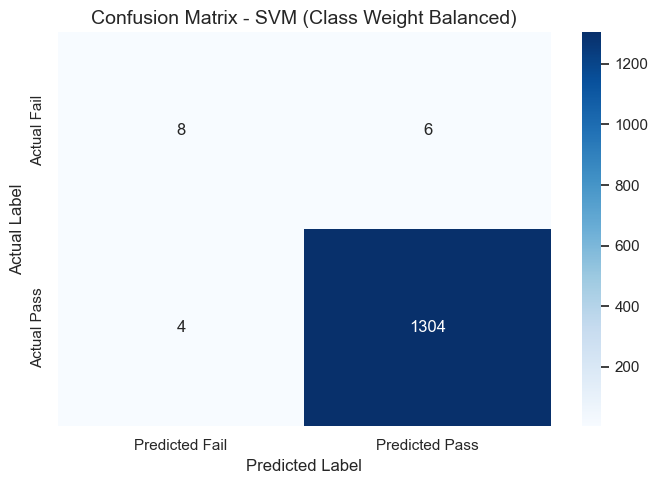

In [15]:
# Cell 14 - Train and Evaluate Class-Weighted Models

imbalance_results = []
weighted_pipelines = {}

for model_name, model in weighted_models.items():
    print("=" * 80)
    print(f"Training class-weighted model: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    result = evaluate_model(
        model_name=model_name,
        strategy="Class Weight Balanced",
        y_true=y_test,
        y_pred=y_pred
    )

    imbalance_results.append(result)
    weighted_pipelines[model_name] = pipeline

    print(classification_report(
        y_test,
        y_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    ))

    plot_confusion_matrix(
        model_name=model_name,
        strategy="Class Weight Balanced",
        y_true=y_test,
        y_pred=y_pred
    )

In [16]:
# Cell 15 - Create and Save Class-Weight Results Table

class_weight_results_df = pd.DataFrame(imbalance_results)

metric_columns = [
    "Accuracy",
    "Precision_Weighted",
    "Recall_Weighted",
    "F1_Weighted",
    "Macro_F1",
    "Balanced_Accuracy",
    "Fail_Recall",
    "Fail_Precision",
    "Pass_Recall"
]

class_weight_results_df[metric_columns] = class_weight_results_df[metric_columns].round(4)

class_weight_results_df = class_weight_results_df.sort_values(
    by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    ascending=False
).reset_index(drop=True)

class_weight_results_path = TABLES_DIR / "class_weight_results.csv"
class_weight_results_df.to_csv(class_weight_results_path, index=False)

print("Class-weight results saved successfully.")
print("Saved to:", class_weight_results_path)

class_weight_results_df

Class-weight results saved successfully.
Saved to: ..\outputs\tables\class_weight_results.csv


,Model,Strategy,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall
0,Logistic Regression,Class Weight Balanced,0.9887,0.9945,0.9887,0.9906,0.8227,0.9943,1.0000,0.4828,0.9885
1,SVM,Class Weight Balanced,0.9924,0.9919,0.9924,0.9921,0.8058,0.7842,0.5714,0.6667,0.9969
2,Decision Tree,Class Weight Balanced,0.9864,0.9854,0.9864,0.9859,0.6504,0.6398,0.2857,0.3333,0.9939
3,Random Forest,Class Weight Balanced,0.9894,0.9789,0.9894,0.9841,0.4973,0.5000,0.0000,0.0000,1.0000


In [17]:
# Cell 16 - Define SMOTE Models

smote_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

Training SMOTE model: Logistic Regression
              precision    recall  f1-score   support

        Fail       0.62      0.93      0.74        14
        Pass       1.00      0.99      1.00      1308

    accuracy                           0.99      1322
   macro avg       0.81      0.96      0.87      1322
weighted avg       1.00      0.99      0.99      1322



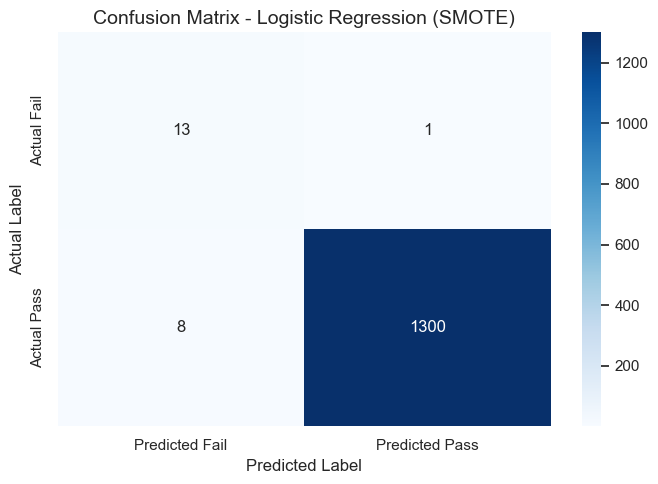

Training SMOTE model: Decision Tree
              precision    recall  f1-score   support

        Fail       0.20      0.29      0.24        14
        Pass       0.99      0.99      0.99      1308

    accuracy                           0.98      1322
   macro avg       0.60      0.64      0.61      1322
weighted avg       0.98      0.98      0.98      1322



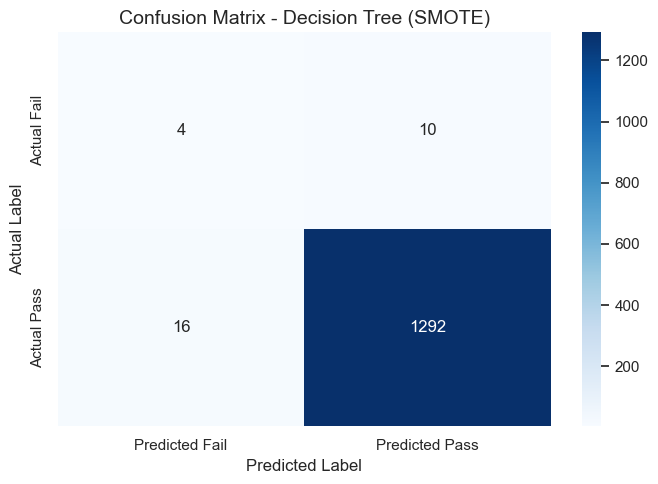

Training SMOTE model: Random Forest
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        14
        Pass       0.99      1.00      0.99      1308

    accuracy                           0.99      1322
   macro avg       0.49      0.50      0.50      1322
weighted avg       0.98      0.99      0.98      1322



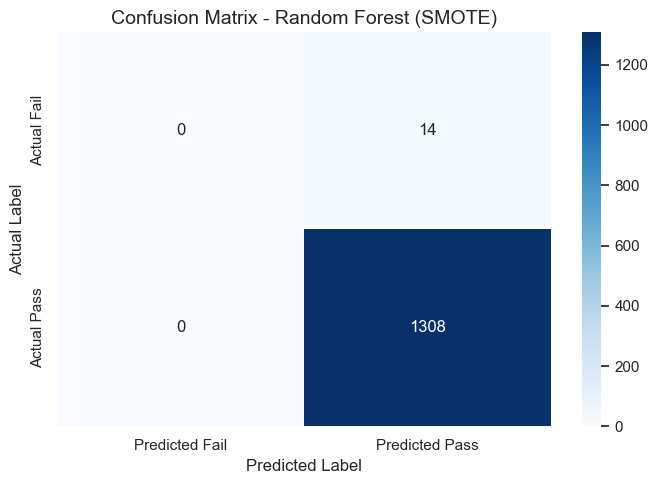

In [18]:
# Cell 17 - Train and Evaluate SMOTE Models

smote_results = []
smote_pipelines = {}

if IMBLEARN_AVAILABLE:
    for model_name, model in smote_models.items():
        print("=" * 80)
        print(f"Training SMOTE model: {model_name}")

        pipeline = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42, k_neighbors=3)),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        result = evaluate_model(
            model_name=model_name,
            strategy="SMOTE",
            y_true=y_test,
            y_pred=y_pred
        )

        smote_results.append(result)
        smote_pipelines[model_name] = pipeline

        print(classification_report(
            y_test,
            y_pred,
            target_names=["Fail", "Pass"],
            zero_division=0
        ))

        plot_confusion_matrix(
            model_name=model_name,
            strategy="SMOTE",
            y_true=y_test,
            y_pred=y_pred
        )
else:
    print("SMOTE experiments skipped because imbalanced-learn is not installed.")

In [19]:
# Cell 18 - SMOTE Results Table

if len(smote_results) > 0:
    smote_results_df = pd.DataFrame(smote_results)
    smote_results_df[metric_columns] = smote_results_df[metric_columns].round(4)

    smote_results_df = smote_results_df.sort_values(
        by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
        ascending=False
    ).reset_index(drop=True)

    smote_results_path = TABLES_DIR / "smote_results.csv"
    smote_results_df.to_csv(smote_results_path, index=False)

    print("SMOTE results saved successfully.")
    print("Saved to:", smote_results_path)

    display(smote_results_df)
else:
    smote_results_df = pd.DataFrame()
    print("No SMOTE results available.")

SMOTE results saved successfully.
Saved to: ..\outputs\tables\smote_results.csv


,Model,Strategy,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall
0,Logistic Regression,SMOTE,0.9932,0.9952,0.9932,0.9939,0.8697,0.9612,0.9286,0.619,0.9939
1,Decision Tree,SMOTE,0.9803,0.9839,0.9803,0.9820,0.6127,0.6367,0.2857,0.200,0.9878
2,Random Forest,SMOTE,0.9894,0.9789,0.9894,0.9841,0.4973,0.5000,0.0000,0.000,1.0000


In [20]:
# Cell 19 - Cross Validation and Scoring

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "recall_fail": make_scorer(recall_score, pos_label=0, zero_division=0)
}

print("Cross-validation setup ready.")

Cross-validation setup ready.


In [21]:
# Cell 20 - Logistic Regression Tuning

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear"]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("\nBest CV Macro F1:")
print(lr_grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression Parameters:
{'model__C': 100, 'model__class_weight': None, 'model__solver': 'liblinear'}

Best CV Macro F1:
0.9490623602181335


              precision    recall  f1-score   support

        Fail       0.91      0.71      0.80        14
        Pass       1.00      1.00      1.00      1308

    accuracy                           1.00      1322
   macro avg       0.95      0.86      0.90      1322
weighted avg       1.00      1.00      1.00      1322



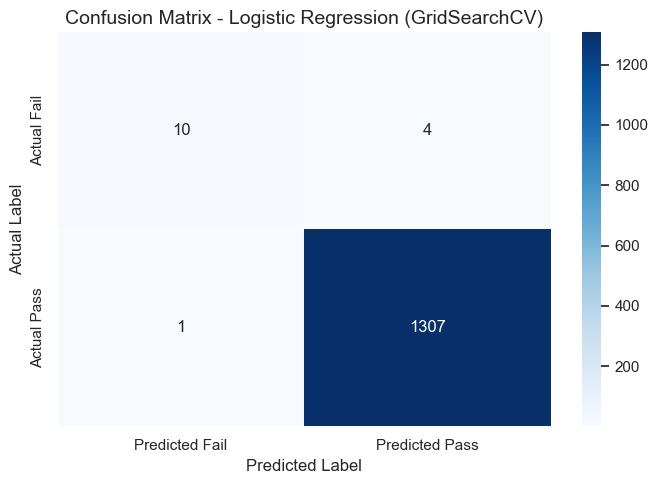

array([[  10,    4],
       [   1, 1307]])

In [22]:
# Cell 21 - Evaluate Tuned Logistic Regression

tuned_results = []
tuned_pipelines = {}

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)

tuned_results.append(evaluate_model(
    model_name="Logistic Regression",
    strategy="GridSearchCV",
    y_true=y_test,
    y_pred=y_pred_lr
))

tuned_pipelines["Logistic Regression"] = best_lr

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Fail", "Pass"],
    zero_division=0
))

plot_confusion_matrix(
    model_name="Logistic Regression",
    strategy="GridSearchCV",
    y_true=y_test,
    y_pred=y_pred_lr
)

In [23]:
# Cell 22 - Decision Tree Tuning

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__class_weight": [None, "balanced"]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest CV Macro F1:")
print(dt_grid.best_score_)

Fitting 5 folds for each of 256 candidates, totalling 1280 fits
Best Decision Tree Parameters:
{'model__class_weight': None, 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}

Best CV Macro F1:
0.7197620430878726


              precision    recall  f1-score   support

        Fail       0.19      0.21      0.20        14
        Pass       0.99      0.99      0.99      1308

    accuracy                           0.98      1322
   macro avg       0.59      0.60      0.60      1322
weighted avg       0.98      0.98      0.98      1322



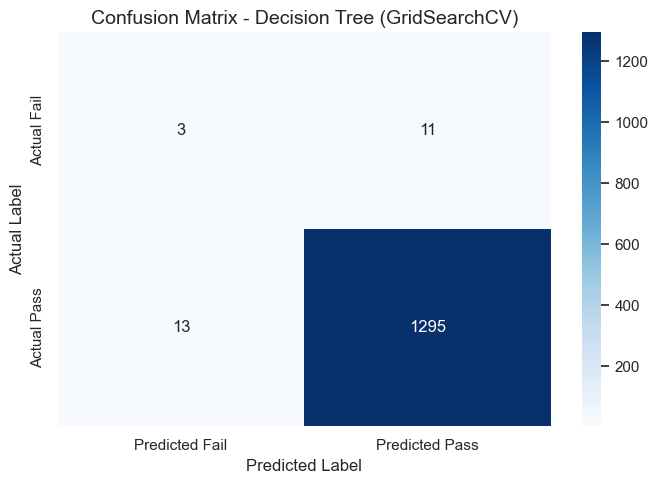

array([[   3,   11],
       [  13, 1295]])

In [24]:
# Cell 23 - Evaluate Tuned Decision Tree

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

tuned_results.append(evaluate_model(
    model_name="Decision Tree",
    strategy="GridSearchCV",
    y_true=y_test,
    y_pred=y_pred_dt
))

tuned_pipelines["Decision Tree"] = best_dt

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Fail", "Pass"],
    zero_division=0
))

plot_confusion_matrix(
    model_name="Decision Tree",
    strategy="GridSearchCV",
    y_true=y_test,
    y_pred=y_pred_dt
)

In [25]:
# Cell 24 - Random Forest Tuning

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_leaf": [1, 2, 5],
    "model__class_weight": [None, "balanced", "balanced_subsample"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Macro F1:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Random Forest Parameters:
{'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

Best CV Macro F1:
0.7388999333905077


              precision    recall  f1-score   support

        Fail       0.33      0.64      0.44        14
        Pass       1.00      0.99      0.99      1308

    accuracy                           0.98      1322
   macro avg       0.66      0.81      0.72      1322
weighted avg       0.99      0.98      0.99      1322



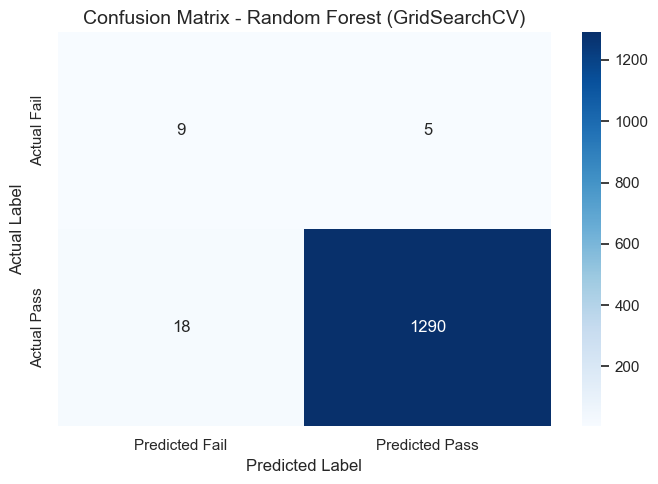

array([[   9,    5],
       [  18, 1290]])

In [26]:
# Cell 25 - Evaluate Tuned Random Forest

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

tuned_results.append(evaluate_model(
    model_name="Random Forest",
    strategy="GridSearchCV",
    y_true=y_test,
    y_pred=y_pred_rf
))

tuned_pipelines["Random Forest"] = best_rf

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Fail", "Pass"],
    zero_division=0
))

plot_confusion_matrix(
    model_name="Random Forest",
    strategy="GridSearchCV",
    y_true=y_test,
    y_pred=y_pred_rf
)

In [27]:
# Cell 26 - Tuned Results Table

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df[metric_columns] = tuned_results_df[metric_columns].round(4)

tuned_results_df = tuned_results_df.sort_values(
    by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    ascending=False
).reset_index(drop=True)

tuning_results_path = TABLES_DIR / "tuning_results.csv"
tuned_results_df.to_csv(tuning_results_path, index=False)

print("Tuning results saved successfully.")
print("Saved to:", tuning_results_path)

tuned_results_df

Tuning results saved successfully.
Saved to: ..\outputs\tables\tuning_results.csv


,Model,Strategy,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall
0,Logistic Regression,GridSearchCV,0.9962,0.9960,0.9962,0.9960,0.8990,0.8568,0.7143,0.9091,0.9992
1,Random Forest,GridSearchCV,0.9826,0.9891,0.9826,0.9853,0.7151,0.8145,0.6429,0.3333,0.9862
2,Decision Tree,GridSearchCV,0.9818,0.9831,0.9818,0.9824,0.5954,0.6022,0.2143,0.1875,0.9901


In [28]:
# Cell 27 - Threshold Evaluation Function

def evaluate_thresholds(model_name, pipeline, X_test, y_test, thresholds):
    pass_prob = pipeline.predict_proba(X_test)[:, 1]

    threshold_results = []

    for threshold in thresholds:
        y_pred_threshold = np.where(pass_prob >= threshold, 1, 0)

        result = evaluate_model(
            model_name=model_name,
            strategy=f"Threshold={threshold:.2f}",
            y_true=y_test,
            y_pred=y_pred_threshold
        )

        result["Threshold"] = threshold
        threshold_results.append(result)

    return pd.DataFrame(threshold_results)

In [29]:
# Cell 28 - Apply Threshold Tuning on Best Logistic Regression

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results_lr = evaluate_thresholds(
    model_name="Logistic Regression",
    pipeline=best_lr,
    X_test=X_test,
    y_test=y_test,
    thresholds=thresholds
)

threshold_results_lr[metric_columns + ["Threshold"]] = threshold_results_lr[metric_columns + ["Threshold"]].round(4)

threshold_results_lr.sort_values(
    by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    ascending=False
).head(10)

,Model,Strategy,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall,Threshold
14,Logistic Regression,Threshold=0.80,0.9970,0.9973,0.9970,0.9971,0.9326,0.9631,0.9286,0.8125,0.9977,0.80
13,Logistic Regression,Threshold=0.75,0.9970,0.9970,0.9970,0.9970,0.9278,0.9278,0.8571,0.8571,0.9985,0.75
10,Logistic Regression,Threshold=0.60,0.9970,0.9969,0.9970,0.9969,0.9223,0.8925,0.7857,0.9167,0.9992,0.60
11,Logistic Regression,Threshold=0.65,0.9970,0.9969,0.9970,0.9969,0.9223,0.8925,0.7857,0.9167,0.9992,0.65
15,Logistic Regression,Threshold=0.85,0.9962,0.9968,0.9962,0.9964,0.9184,0.9628,0.9286,0.7647,0.9969,0.85
16,Logistic Regression,Threshold=0.90,0.9962,0.9968,0.9962,0.9964,0.9184,0.9628,0.9286,0.7647,0.9969,0.90
12,Logistic Regression,Threshold=0.70,0.9962,0.9961,0.9962,0.9961,0.9065,0.8921,0.7857,0.8462,0.9985,0.70
7,Logistic Regression,Threshold=0.45,0.9962,0.9960,0.9962,0.9960,0.8990,0.8568,0.7143,0.9091,0.9992,0.45
8,Logistic Regression,Threshold=0.50,0.9962,0.9960,0.9962,0.9960,0.8990,0.8568,0.7143,0.9091,0.9992,0.50
9,Logistic Regression,Threshold=0.55,0.9962,0.9960,0.9962,0.9960,0.8990,0.8568,0.7143,0.9091,0.9992,0.55


In [30]:
# Cell 29 - Select Best Threshold

best_threshold_row = threshold_results_lr.sort_values(
    by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold for Logistic Regression:")
print(best_threshold)

best_threshold_row

Best Threshold for Logistic Regression:
0.8


Model                 Logistic Regression
Strategy                   Threshold=0.80
Accuracy                            0.997
Precision_Weighted                 0.9973
Recall_Weighted                     0.997
F1_Weighted                        0.9971
Macro_F1                           0.9326
Balanced_Accuracy                  0.9631
Fail_Recall                        0.9286
Fail_Precision                     0.8125
Pass_Recall                        0.9977
Threshold                             0.8
Name: 14, dtype: object

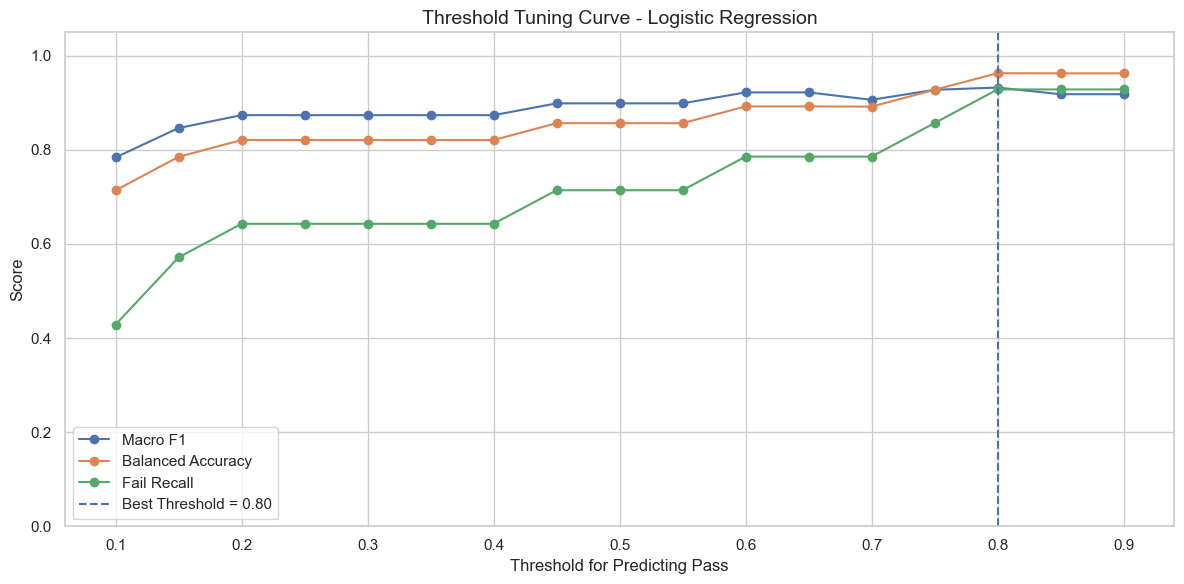

In [31]:
# Cell 30 - Plot Threshold Tuning Curve

plt.figure(figsize=(12, 6))

plt.plot(threshold_results_lr["Threshold"], threshold_results_lr["Macro_F1"], marker="o", label="Macro F1")
plt.plot(threshold_results_lr["Threshold"], threshold_results_lr["Balanced_Accuracy"], marker="o", label="Balanced Accuracy")
plt.plot(threshold_results_lr["Threshold"], threshold_results_lr["Fail_Recall"], marker="o", label="Fail Recall")

plt.axvline(best_threshold, linestyle="--", label=f"Best Threshold = {best_threshold:.2f}")

plt.title("Threshold Tuning Curve - Logistic Regression", fontsize=14)
plt.xlabel("Threshold for Predicting Pass")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_tuning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
# Cell 31 - Evaluate Best Threshold Prediction

pass_prob = best_lr.predict_proba(X_test)[:, 1]
y_pred_best_threshold = np.where(pass_prob >= best_threshold, 1, 0)

threshold_final_result = evaluate_model(
    model_name="Logistic Regression",
    strategy=f"Best Threshold={best_threshold:.2f}",
    y_true=y_test,
    y_pred=y_pred_best_threshold
)

threshold_final_df = pd.DataFrame([threshold_final_result])
threshold_final_df[metric_columns] = threshold_final_df[metric_columns].round(4)

threshold_final_df

,Model,Strategy,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall
0,Logistic Regression,Best Threshold=0.80,0.997,0.9973,0.997,0.9971,0.9326,0.9631,0.9286,0.8125,0.9977


              precision    recall  f1-score   support

        Fail       0.81      0.93      0.87        14
        Pass       1.00      1.00      1.00      1308

    accuracy                           1.00      1322
   macro avg       0.91      0.96      0.93      1322
weighted avg       1.00      1.00      1.00      1322



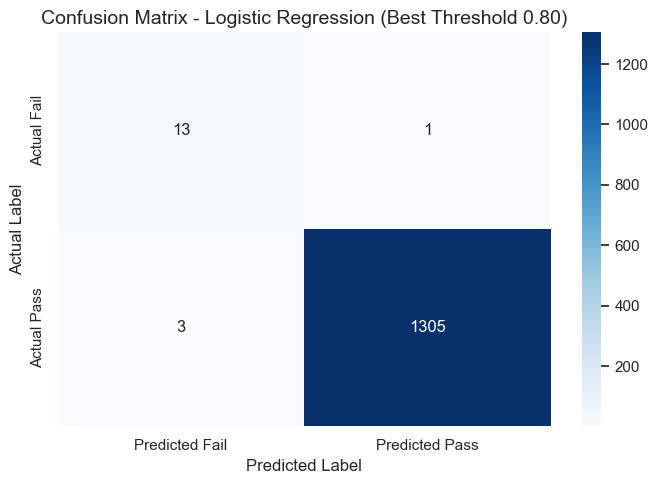

array([[  13,    1],
       [   3, 1305]])

In [33]:
# Cell 32 - Confusion Matrix for Best Threshold

print(classification_report(
    y_test,
    y_pred_best_threshold,
    target_names=["Fail", "Pass"],
    zero_division=0
))

plot_confusion_matrix(
    model_name="Logistic Regression",
    strategy=f"Best Threshold {best_threshold:.2f}",
    y_true=y_test,
    y_pred=y_pred_best_threshold
)

In [34]:
# Cell 33 - Combine All Results Safely

all_results_list = []

if "class_weight_results_df" in globals() and len(class_weight_results_df) > 0:
    all_results_list.append(class_weight_results_df)
else:
    print("class_weight_results_df not found or empty.")

if "tuned_results_df" in globals() and len(tuned_results_df) > 0:
    all_results_list.append(tuned_results_df)
else:
    print("tuned_results_df not found or empty.")

if "threshold_final_df" in globals() and len(threshold_final_df) > 0:
    all_results_list.append(threshold_final_df)
else:
    print("threshold_final_df not found or empty.")

if "smote_results_df" in globals() and len(smote_results_df) > 0:
    all_results_list.append(smote_results_df)
else:
    print("smote_results_df not found or empty.")

if len(all_results_list) > 0:
    all_improvement_results_df = pd.concat(all_results_list, ignore_index=True)

    all_improvement_results_df[metric_columns] = all_improvement_results_df[metric_columns].round(4)

    all_improvement_results_df = all_improvement_results_df.sort_values(
        by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
        ascending=False
    ).reset_index(drop=True)

    display(all_improvement_results_df)
else:
    raise ValueError("No result DataFrames are available. Please run the previous cells first.")

,Model,Strategy,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall
0,Logistic Regression,Best Threshold=0.80,0.9970,0.9973,0.9970,0.9971,0.9326,0.9631,0.9286,0.8125,0.9977
1,Logistic Regression,GridSearchCV,0.9962,0.9960,0.9962,0.9960,0.8990,0.8568,0.7143,0.9091,0.9992
2,Logistic Regression,SMOTE,0.9932,0.9952,0.9932,0.9939,0.8697,0.9612,0.9286,0.6190,0.9939
3,Logistic Regression,Class Weight Balanced,0.9887,0.9945,0.9887,0.9906,0.8227,0.9943,1.0000,0.4828,0.9885
4,SVM,Class Weight Balanced,0.9924,0.9919,0.9924,0.9921,0.8058,0.7842,0.5714,0.6667,0.9969
5,Random Forest,GridSearchCV,0.9826,0.9891,0.9826,0.9853,0.7151,0.8145,0.6429,0.3333,0.9862
6,Decision Tree,Class Weight Balanced,0.9864,0.9854,0.9864,0.9859,0.6504,0.6398,0.2857,0.3333,0.9939
7,Decision Tree,SMOTE,0.9803,0.9839,0.9803,0.9820,0.6127,0.6367,0.2857,0.2000,0.9878
8,Decision Tree,GridSearchCV,0.9818,0.9831,0.9818,0.9824,0.5954,0.6022,0.2143,0.1875,0.9901
9,Random Forest,Class Weight Balanced,0.9894,0.9789,0.9894,0.9841,0.4973,0.5000,0.0000,0.0000,1.0000


In [35]:
# Cell 34 - Save All Improvement Results

threshold_results_path = TABLES_DIR / "threshold_tuning_results.csv"
all_results_path = TABLES_DIR / "all_improvement_results.csv"

threshold_results_lr.to_csv(threshold_results_path, index=False)
all_improvement_results_df.to_csv(all_results_path, index=False)

print("Results saved successfully:")
print("-", threshold_results_path)
print("-", all_results_path)

Results saved successfully:
- ..\outputs\tables\threshold_tuning_results.csv
- ..\outputs\tables\all_improvement_results.csv


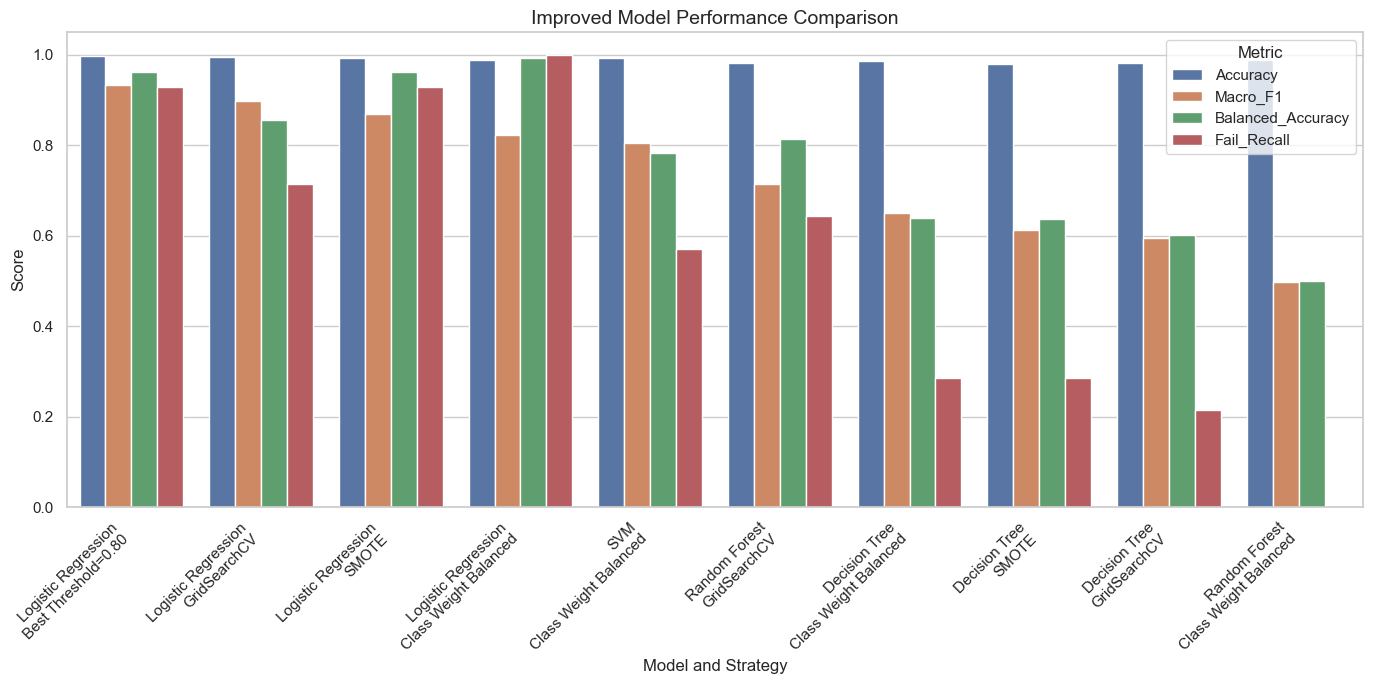

In [36]:
# Cell 35 - Plot Improved Model Comparison

top_results = all_improvement_results_df.head(10).copy()

plt.figure(figsize=(14, 7))

plot_df = top_results.melt(
    id_vars=["Model", "Strategy"],
    value_vars=["Accuracy", "Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    var_name="Metric",
    value_name="Score"
)

plot_df["Model_Strategy"] = plot_df["Model"] + "\n" + plot_df["Strategy"]

sns.barplot(data=plot_df, x="Model_Strategy", y="Score", hue="Metric")

plt.title("Improved Model Performance Comparison", fontsize=14)
plt.xlabel("Model and Strategy")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "improved_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# Cell 36 - Select Best Candidate

best_result = all_improvement_results_df.iloc[0]

print("Best Improved Model Candidate:")
print("-" * 50)
print(best_result)

Best Improved Model Candidate:
--------------------------------------------------
Model                 Logistic Regression
Strategy              Best Threshold=0.80
Accuracy                            0.997
Precision_Weighted                 0.9973
Recall_Weighted                     0.997
F1_Weighted                        0.9971
Macro_F1                           0.9326
Balanced_Accuracy                  0.9631
Fail_Recall                        0.9286
Fail_Precision                     0.8125
Pass_Recall                        0.9977
Name: 0, dtype: object


In [38]:
# Cell 37 - Save Best Candidate Model Pipeline

best_model_name = best_result["Model"]
best_strategy = best_result["Strategy"]

print("Best model name:", best_model_name)
print("Best strategy:", best_strategy)

if best_strategy == "GridSearchCV":
    final_candidate_pipeline = tuned_pipelines[best_model_name]

elif best_strategy == "Class Weight Balanced":
    final_candidate_pipeline = weighted_pipelines[best_model_name]

elif best_strategy == "SMOTE" and "smote_pipelines" in globals():
    final_candidate_pipeline = smote_pipelines[best_model_name]

elif "Best Threshold" in best_strategy:
    final_candidate_pipeline = best_lr

else:
    final_candidate_pipeline = best_lr
    print("Fallback: using tuned Logistic Regression pipeline.")

candidate_model_path = MODELS_DIR / "best_candidate_model_from_04.pkl"

joblib.dump(final_candidate_pipeline, candidate_model_path)

print("Best candidate pipeline saved successfully.")
print("Saved to:", candidate_model_path)

Best model name: Logistic Regression
Best strategy: Best Threshold=0.80
Best candidate pipeline saved successfully.
Saved to: ..\outputs\models\best_candidate_model_from_04.pkl


In [39]:
# Cell 38 - Save Best Threshold Info

threshold_info = {
    "best_threshold_for_pass_probability": float(best_threshold),
    "note": "If P(Pass) >= threshold, predict Pass; otherwise predict Fail."
}

threshold_info_path = MODELS_DIR / "best_threshold_info.pkl"

joblib.dump(threshold_info, threshold_info_path)

print("Threshold info saved successfully.")
print("Saved to:", threshold_info_path)

Threshold info saved successfully.
Saved to: ..\outputs\models\best_threshold_info.pkl


In [40]:
# Cell 39 - Save Final Improvement Summary Text

improvement_summary_path = TABLES_DIR / "imbalance_and_tuning_summary.txt"

best_row = all_improvement_results_df.iloc[0]

improvement_summary_text = f"""
Imbalance Handling and Tuning Summary

Main issue:
The dataset is highly imbalanced, with the Fail class representing a very small percentage of the data.

Strategies tested:
1. Class Weight Balanced
2. SMOTE
3. GridSearchCV Hyperparameter Tuning
4. Threshold Tuning

Best final candidate:
Model: {best_row["Model"]}
Strategy: {best_row["Strategy"]}

Performance:
Accuracy: {best_row["Accuracy"]}
Macro F1: {best_row["Macro_F1"]}
Balanced Accuracy: {best_row["Balanced_Accuracy"]}
Fail Recall: {best_row["Fail_Recall"]}
Fail Precision: {best_row["Fail_Precision"]}
Pass Recall: {best_row["Pass_Recall"]}

Reason for selection:
The best model was selected based on Macro F1, Balanced Accuracy, and Fail Recall rather than accuracy only.
This is because the main goal is to detect students at risk of failing.
"""

with open(improvement_summary_path, "w", encoding="utf-8") as file:
    file.write(improvement_summary_text)

print("Imbalance and tuning summary saved successfully.")
print("Saved to:", improvement_summary_path)

Imbalance and tuning summary saved successfully.
Saved to: ..\outputs\tables\imbalance_and_tuning_summary.txt


In [41]:
# Cell 40 - Final Output Check

print("04 Imbalance and Tuning Output Files")
print("-" * 60)

print("\nTables:")
for file in sorted(TABLES_DIR.glob("*.csv")):
    if any(keyword in file.name for keyword in ["weight", "smote", "tuning", "improvement", "results"]):
        print("-", file.name)

print("\nFigures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    if any(keyword in file.name for keyword in ["tuning", "improved", "confusion_matrix"]):
        print("-", file.name)

print("\nModels:")
for file in sorted(MODELS_DIR.glob("*.pkl")):
    print("-", file.name)

print("\nText Summaries:")
for file in sorted(TABLES_DIR.glob("*.txt")):
    if "tuning" in file.name or "imbalance" in file.name:
        print("-", file.name)

04 Imbalance and Tuning Output Files
------------------------------------------------------------

Tables:
- all_improvement_results.csv
- baseline_results.csv
- class_weight_results.csv
- smote_results.csv
- threshold_tuning_results.csv
- tuning_results.csv

Figures:
- confusion_matrix_decision_tree_baseline.png
- confusion_matrix_decision_tree_class_weight_balanced.png
- confusion_matrix_decision_tree_gridsearchcv.png
- confusion_matrix_decision_tree_smote.png
- confusion_matrix_gradient_boosting_baseline.png
- confusion_matrix_logistic_regression_baseline.png
- confusion_matrix_logistic_regression_best_threshold_0.80.png
- confusion_matrix_logistic_regression_class_weight_balanced.png
- confusion_matrix_logistic_regression_gridsearchcv.png
- confusion_matrix_logistic_regression_smote.png
- confusion_matrix_random_forest_baseline.png
- confusion_matrix_random_forest_class_weight_balanced.png
- confusion_matrix_random_forest_gridsearchcv.png
- confusion_matrix_random_forest_smote.png


# Cell 41 - Markdown
"""
## Imbalance Handling and Tuning Summary

This notebook improved the baseline models by applying:

1. Class weighting
2. SMOTE oversampling
3. GridSearchCV hyperparameter tuning
4. Threshold tuning

The results confirm that accuracy alone is not suitable for this project because the dataset is highly imbalanced.

The final candidate model was selected based on:
- Macro F1-score
- Balanced Accuracy
- Fail Recall
- Confusion Matrix

The next notebook will focus on final model evaluation and explainability.
"""